## Imports

In [2]:
import pandas as pd
import random
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2
import numpy as np

from preprocessing import extract_bounding_boxes_from_txt, create_dataframe, find_image_path, plot_random_images_with_bboxes, plot_class_images_with_bboxes, filter_images_and_df_by_size, crop_random_placement 





## Image Loading and Visualization

In [83]:
# Folder path where the images and text files are located
cow_image_folder = '../AWIR/Cow'

# Create separate DataFrames for RGB and thermal images
rgb_df_cow = create_dataframe(cow_image_folder, '.jpg')
thermal_df_cow = create_dataframe(cow_image_folder, '_R.JPG', thermal=True)


In [85]:
# Folder path where the images and text files are located
deer_image_folder = '/blue/azare/zhou.m/awir/data/AWIR/Deer'

# Create separate DataFrames for RGB and thermal images
rgb_df_deer = create_dataframe(deer_image_folder, '.JPG', obj_class='deer')
thermal_df_deer = create_dataframe(deer_image_folder, '_R.JPG', thermal=True, obj_class='deer')

In [86]:
# Folder path where the images and text files are located
horse_image_folder = '/blue/azare/zhou.m/awir/data/AWIR/Horse'

# Create separate DataFrames for RGB and thermal images
rgb_df_horse = create_dataframe(horse_image_folder, '.JPG', obj_class='horse')
thermal_df_horse = create_dataframe(horse_image_folder, '_R.JPG', thermal=True, obj_class='horse')

In [87]:
rgb_df = pd.concat([rgb_df_horse, rgb_df_deer, rgb_df_cow], ignore_index=True)
thermal_df = pd.concat([thermal_df_horse, thermal_df_deer, thermal_df_cow], ignore_index=True)

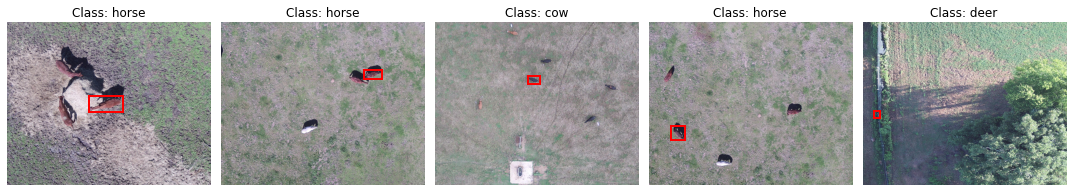

In [88]:
# Folder where the images are stored
image_folder = '/blue/azare/zhou.m/awir/data/AWIR'

# Call the function to plot 5 random images
plot_random_images_with_bboxes(rgb_df, image_folder, num_images=5)

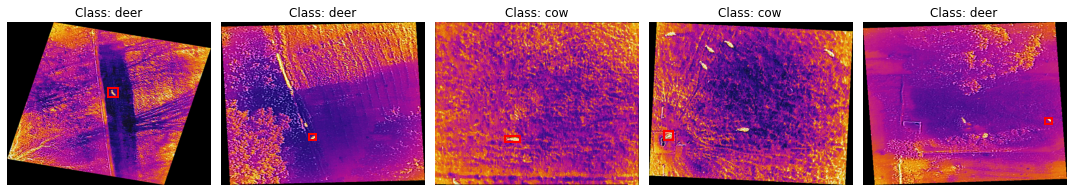

In [89]:
# Folder where the images are stored
image_folder = '/blue/azare/zhou.m/awir/data/AWIR'

# Call the function to plot 5 random images
plot_random_images_with_bboxes(thermal_df, image_folder, num_images=5)

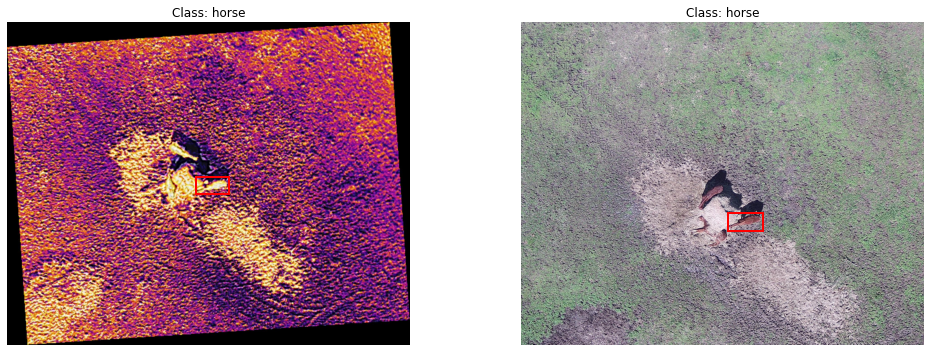

In [90]:
plot_class_images_with_bboxes(rgb_df, image_folder, animal_class='horse', num_images=2)

## Image Cropping

In [320]:
# Merging based on the specified columns
merged_df = pd.merge(
    rgb_df, thermal_df, 
    on=['x_center', 'y_center', 'width', 'height', 'class'], 
    suffixes=('_rgb', '_thermal')
)

# Rename the image_name columns
merged_df.rename(columns={'image_name_rgb': 'rgb_image_name', 'image_name_thermal': 'thermal_image_name'}, inplace=True)

merged_df

,rgb_image_name,x_center,y_center,width,height,class,thermal_image_name
0,H_DJI_0648.JPG,0.381757,0.644596,0.087838,0.061216,horse,H_DJI_0647_R.JPG
1,H_DJI_0647_R.JPG,0.381757,0.644596,0.087838,0.061216,horse,H_DJI_0647_R.JPG
2,H_DJI_0648.JPG,0.494088,0.639319,0.096284,0.063327,horse,H_DJI_0647_R.JPG
3,H_DJI_0647_R.JPG,0.494088,0.639319,0.096284,0.063327,horse,H_DJI_0647_R.JPG
4,H_DJI_0648.JPG,0.190034,0.970730,0.092905,0.054883,horse,H_DJI_0647_R.JPG
...,...,...,...,...,...,...,...
667,CE_DJI_0516.jpg,0.714527,0.931679,0.043919,0.082325,cow,CE_DJI_0515_R.JPG
668,CE_DJI_0520.jpg,0.742399,0.199197,0.038851,0.078103,cow,CE_DJI_0519_R.JPG
669,CE_DJI_0446.jpg,0.364865,0.045102,0.067568,0.065438,cow,CE_DJI_0445_R.JPG
670,CE_DJI_0446.jpg,0.699324,0.190754,0.057432,0.065438,cow,CE_DJI_0445_R.JPG


In [321]:
# Filter out rows where 'thermal_image_name' is NaN
filtered_df = merged_df[merged_df['thermal_image_name'].notna()]

# Remove rows where 'rgb_image_name' and 'thermal_image_name' are the same
filtered_df = filtered_df[filtered_df['rgb_image_name'] != filtered_df['thermal_image_name']]

filtered_df

,rgb_image_name,x_center,y_center,width,height,class,thermal_image_name
0,H_DJI_0648.JPG,0.381757,0.644596,0.087838,0.061216,horse,H_DJI_0647_R.JPG
2,H_DJI_0648.JPG,0.494088,0.639319,0.096284,0.063327,horse,H_DJI_0647_R.JPG
4,H_DJI_0648.JPG,0.190034,0.970730,0.092905,0.054883,horse,H_DJI_0647_R.JPG
6,H_DJI_0590.JPG,0.240240,0.388600,0.045983,0.078572,horse,H_DJI_0589_R.JPG
8,H_DJI_0590.JPG,0.273555,0.633699,0.046922,0.062154,horse,H_DJI_0589_R.JPG
...,...,...,...,...,...,...,...
667,CE_DJI_0516.jpg,0.714527,0.931679,0.043919,0.082325,cow,CE_DJI_0515_R.JPG
668,CE_DJI_0520.jpg,0.742399,0.199197,0.038851,0.078103,cow,CE_DJI_0519_R.JPG
669,CE_DJI_0446.jpg,0.364865,0.045102,0.067568,0.065438,cow,CE_DJI_0445_R.JPG
670,CE_DJI_0446.jpg,0.699324,0.190754,0.057432,0.065438,cow,CE_DJI_0445_R.JPG


In [ ]:
# Perform the cropping and update the DataFrame with adjusted bounding box coordinates
rgb_cropped_images, thermal_cropped_images, updated_df = crop_random_placement(filtered_df, image_folder, image_folder, crop_size=300)


In [326]:
target_size = (300, 300)
filtered_rgb_cropped_images, filtered_thermal_cropped_images, filtered_df = filter_images_and_df_by_size(updated_df, rgb_cropped_images, thermal_cropped_images, target_size)


In [498]:
filtered_df, filtered_rgb_cropped_images, filtered_thermal_cropped_images = remove_index(190, filtered_df, filtered_rgb_cropped_images, filtered_thermal_cropped_images)

## Checking Cropped Images

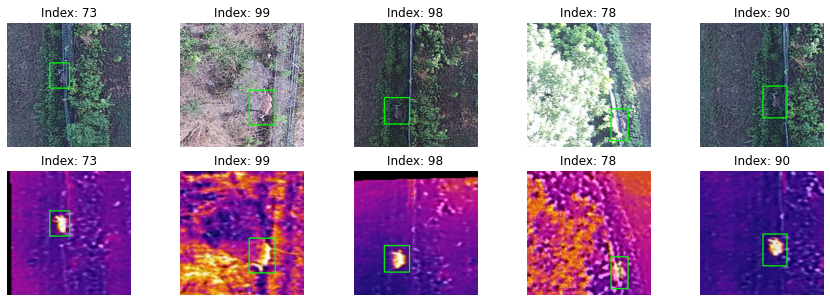

In [496]:
plot_images_by_class(filtered_df, filtered_rgb_cropped_images, filtered_thermal_cropped_images, target_class='deer', n_examples=5)

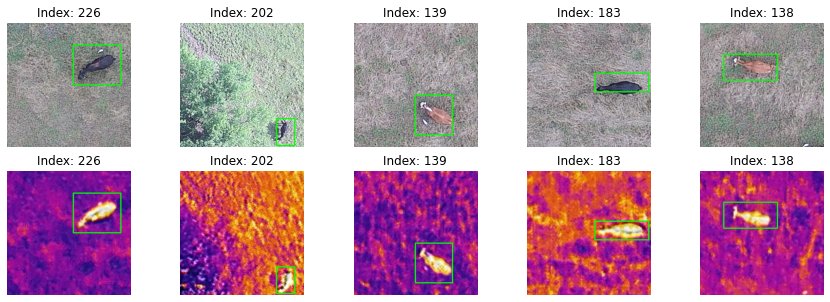

In [499]:
plot_images_by_class(filtered_df, filtered_rgb_cropped_images, filtered_thermal_cropped_images, target_class='cow', n_examples=5)

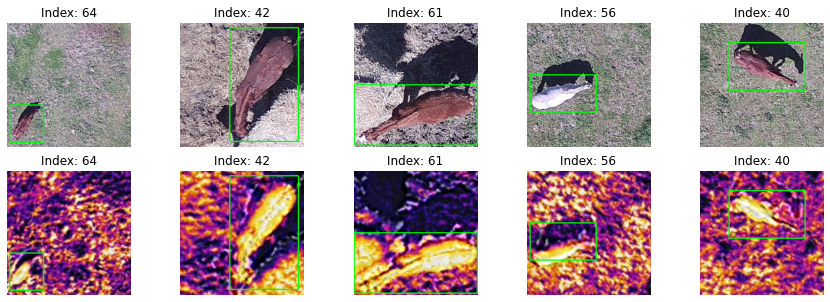

In [507]:
plot_images_by_class(filtered_df, filtered_rgb_cropped_images, filtered_thermal_cropped_images, target_class='horse', n_examples=5)

In [456]:
# Convert the coordinates for filtered_df
filtered_df = convert_to_pixel_coordinates(filtered_df, img_width=300, img_height=300)

In [477]:
filtered_thermal_cropped_images[0].min(),filtered_thermal_cropped_images[0].max(), filtered_thermal_cropped_images[0].mean()

(0, 255, 98.61624444444445)

In [479]:
filtered_rgb_cropped_images[0].min(),filtered_rgb_cropped_images[0].max(), filtered_rgb_cropped_images[0].mean()

(0, 255, 132.79304444444443)

In [501]:
# Initialize lists to store data for each key
rgb_images = []
thermal_images = []
boxes = []
classes = []
rgb_image_names = []
thermal_image_names = []

# Iterate through the filtered DataFrame and gather the necessary information
for idx, row in filtered_df.iterrows():
    # Append the RGB and thermal cropped images
    rgb_images.append(filtered_rgb_cropped_images[idx])
    thermal_images.append(filtered_thermal_cropped_images[idx])
    
    # Append the bounding box as [xmin, xmax, ymin, ymax]
    box = [row['xmin'], row['xmax'], row['ymin'], row['ymax']]
    boxes.append(box)
    
    # Append the class label
    classes.append(row['class'])
    
    # Append the image names
    rgb_image_names.append(row['rgb_image_name'])
    thermal_image_names.append(row['thermal_image_name'])

# Convert the lists to numpy arrays
rgb_images_np = np.array(rgb_images)
thermal_images_np = np.array(thermal_images)
boxes_np = np.array(boxes)
classes_np = np.array(classes)
rgb_image_names_np = np.array(rgb_image_names)
thermal_image_names_np = np.array(thermal_image_names)

# Save the data as an .npz file with the specified keys
np.savez('data.npz', 
         rgb=rgb_images_np, 
         thermal=thermal_images_np, 
         box_label=boxes_np, 
         class_label=classes_np, 
         rgb_image_name=rgb_image_names_np, 
         thermal_image_name=thermal_image_names_np)

## Checking saved NPZ file

In [502]:
f = np.load('data.npz')
f.files

['rgb',
 'thermal',
 'box_label',
 'class_label',
 'rgb_image_name',
 'thermal_image_name']

(-0.5, 299.5, 299.5, -0.5)

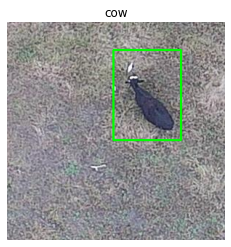

In [503]:

index=200

x_min = int(f['box_label'][index][0])
x_max = int(f['box_label'][index][1])
y_min = int(f['box_label'][index][2])
y_max = int(f['box_label'][index][3])

rgb_img_with_box = f['rgb'][index].copy()
cv2.rectangle(rgb_img_with_box, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)  # Green bounding box
plt.imshow(cv2.cvtColor(rgb_img_with_box, cv2.COLOR_BGR2RGB))
plt.title(f['class_label'][index])

plt.axis('off')

## Converting back to center coordinates + height + width

In [35]:
f = np.load('data.npz')


box_labels = f['box_label']
y_box = f['box_label']
class_labels = f['class_label']
rgb_images = f['rgb']
thermal_images = f['thermal']
rgb_images.shape

(240, 300, 300, 3)

In [36]:
# Image size (for normalization)
image_width = 300
image_height = 300

# Initialize an array to hold the converted values
# Shape: (num_samples, 4)
num_samples = y_box.shape[0]
y_box_cenwh = np.zeros((num_samples, 4))

# Calculate center x, center y, width, height and normalize
for i in range(num_samples):
    xmin, xmax, ymin, ymax = y_box[i]
    xcenter = (xmin + xmax) / 2
    ycenter = (ymin + ymax) / 2
    width = xmax - xmin
    height = ymax - ymin

    # Normalize by the image size
    y_box_cenwh[i, 0] = xcenter / image_width      # xcenter normalized
    y_box_cenwh[i, 1] = ycenter / image_height     # ycenter normalized
    y_box_cenwh[i, 2] = width / image_width         # width normalized
    y_box_cenwh[i, 3] = height / image_height       # height normalized

In [37]:
y_box_cenwh[0]

array([0.29      , 0.84666667, 0.57333333, 0.3       ])

In [22]:
# Load the array into a DataFrame
df = pd.DataFrame(box_labels, columns=['xmin', 'xmax', 'ymin', 'ymax'])

# Calculate xcenter, ycenter, width, and height
df['xcenter'] = (df['xmin'] + df['xmax']) / 2
df['ycenter'] = (df['ymin'] + df['ymax']) / 2
df['width'] = df['xmax'] - df['xmin']
df['height'] = df['ymax'] - df['ymin']

# Normalize the coordinates based on the image size (300x300)
image_width = 300
image_height = 300

# Add the class labels to the DataFrame
df['class_label'] = class_labels

df['xcenter_normalized'] = df['xcenter'] / image_width
df['ycenter_normalized'] = df['ycenter'] / image_height
df['width_normalized'] = df['width'] / image_width
df['height_normalized'] = df['height'] / image_height

# Drop original columns if you only want the normalized values
# df = df[['xcenter_normalized', 'ycenter_normalized', 'width_normalized', 'height_normalized']]

# Display the resulting DataFrame
df

,xmin,xmax,ymin,ymax,xcenter,ycenter,width,height,class_label,xcenter_normalized,ycenter_normalized,width_normalized,height_normalized
0,1,173,209,299,87.0,254.0,172,90,horse,0.290000,0.846667,0.573333,0.300000
1,64,146,101,213,105.0,157.0,82,112,horse,0.350000,0.523333,0.273333,0.373333
2,170,254,84,173,212.0,128.5,84,89,horse,0.706667,0.428333,0.280000,0.296667
3,118,223,57,104,170.5,80.5,105,47,horse,0.568333,0.268333,0.350000,0.156667
4,142,239,49,92,190.5,70.5,97,43,horse,0.635000,0.235000,0.323333,0.143333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,162,232,149,195,197.0,172.0,70,46,cow,0.656667,0.573333,0.233333,0.153333
236,34,103,136,247,68.5,191.5,69,111,cow,0.228333,0.638333,0.230000,0.370000
237,166,287,17,110,226.5,63.5,121,93,cow,0.755000,0.211667,0.403333,0.310000
238,174,276,127,220,225.0,173.5,102,93,cow,0.750000,0.578333,0.340000,0.310000


In [10]:
# Save the DataFrame as a CSV file
df.to_csv('data_file_box_labels.csv', index=False)

## Creating YOLO Image and Label Directories


In [13]:
# Create the directory structure
base_dir = 'data'
os.makedirs(os.path.join(base_dir, 'images'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'labels'), exist_ok=True)

In [ ]:
# Assume you have 240 images in rgb_images and thermal_images
num_images = 240


# Save RGB images
for i in range(num_images):
    class_label = class_labels[i % len(class_labels)]  # Loop through class labels if more images than classes

    rgb_image_filename = os.path.join('/blue/azare/zhou.m/awir/data/images/', 'rgb_images', f'{class_label}_rgb_{i + 1}.jpg')

    print(rgb_image_filename, rgb_images[i].shape)
    cv2.imwrite(rgb_image_filename, rgb_images[i])

# Save thermal images
for i in range(num_images):
    class_label = class_labels[i % len(class_labels)]  # Loop through class labels if more images than classes
    thermal_image_filename = os.path.join('/blue/azare/zhou.m/awir/data/images/', 'thermal_images', f'{class_label}_thermal_{i + 1}.jpg')
    cv2.imwrite(thermal_image_filename, thermal_images[i])

# Optional: Display confirmation message
#print(f"RGB and thermal images saved in '{base_dir}/rgb_images' and '{base_dir}/thermal_images'.")

In [31]:
rgb_images[0].shape

(300, 300, 3)